<a href="https://colab.research.google.com/github/Fisev/PZP-Project/blob/Petlu/Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

INITIAL SETUP & IMPORTS

In [17]:
import re
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np
import time


#global variables
sections=[]
times=[]
pattern = re.compile(r'[^a-zA-Z]')
min_length = 4
max_length = 8

try:
  #get files
  !wget https://raw.githubusercontent.com/Fisev/PZP-Project/refs/heads/main/data.txt -O data.txt
  !wget https://raw.githubusercontent.com/Fisev/PZP-Project/refs/heads/main/stop_words.txt -O stop_words.txt
  !pip install pycuda

  with open("data.txt", "r") as file:
    raw_text = file.read().lower()

  with open("stop_words.txt", "r") as file:
    f_stopW = set(file.read().lower().split())



  #after successful installing pycuda following import
  from pycuda.compiler import SourceModule
  import pycuda.autoinit
  import pycuda.driver as cuda


  def update_pie_chart(section_name, time_elapsed):

    sections.append(section_name)
    times.append(time_elapsed)


    plt.clf()


    plt.pie(times, labels=sections, autopct=lambda pct: f"{pct * sum(times) / 100:.3f}s", startangle=90)
    plt.title("Time Elapsed for Different Code Sections")
    plt.axis('equal')


    plt.show()



except Exception as e:
    print(f"Reading failed: {e}")


--2024-12-10 08:38:31--  https://raw.githubusercontent.com/Fisev/PZP-Project/refs/heads/main/data.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1257260 (1.2M) [text/plain]
Saving to: ‘data.txt’

data.txt            100%[===================>]   1.20M  --.-KB/s    in 0.01s   

2024-12-10 08:38:32 (110 MB/s) - ‘data.txt’ saved [1257260/1257260]

--2024-12-10 08:38:32--  https://raw.githubusercontent.com/Fisev/PZP-Project/refs/heads/main/stop_words.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 100 [text/plain]
Saving to: ‘

CPU SINGLE TREADED

0.6213536262512207
Most frequent word: 'that' with 3100 occurrences
Least frequent word: 'january' with 1 occurrences
Total number of filtered words: 107668


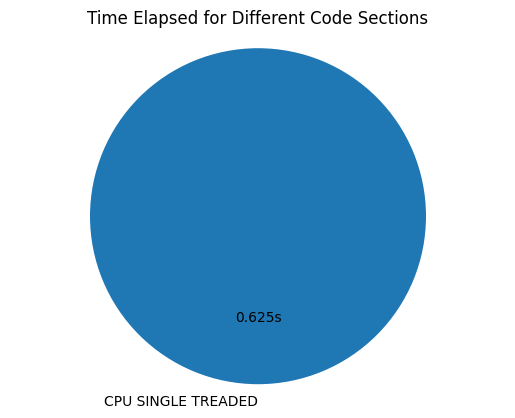

In [18]:
try:
    start_time=time.time()
    words = re.findall(r'\b[a-zA-Z]+(?:-[a-zA-Z]+)?\b', raw_text.lower())

    word_counts = Counter()
    filtered_words = []

    for word in words:
        if min_length <= len(word) <= max_length and word not in f_stopW:
            word_counts[word] += 1
            filtered_words.append(word)

    most_frequent_word, most_frequent_count =   max(word_counts.items(), key = lambda x: x[1])
    least_frequent_word, least_frequent_count = min(word_counts.items(), key = lambda x: x[1])

    total_filtered_words = sum(word_counts.values())
    print(time.time()-start_time)
    # Print the results
    print(f"Most frequent word: '{most_frequent_word}' with {most_frequent_count} occurrences")
    print(f"Least frequent word: '{least_frequent_word}' with {least_frequent_count} occurrences")
    print(f"Total number of filtered words: {total_filtered_words}")
    update_pie_chart("CPU SINGLE TREADED", (time.time()-start_time))
except Exception as e:
    print(f"Reading failed: {e}")

CPU MULTITREADING


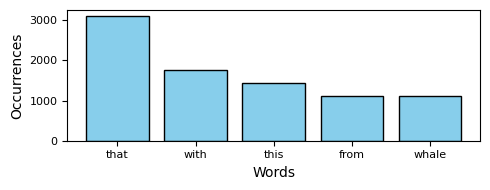

Most frequent word: 'that' with 3100 occurrences
Least frequent word: 'january' with 1 occurrences
Total number of filtered words: 107668


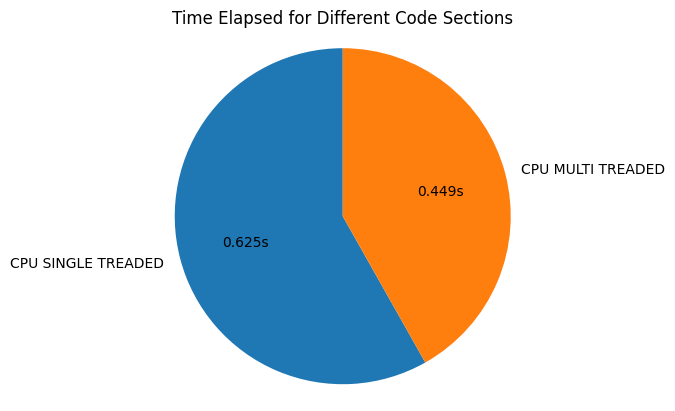

In [19]:
import multiprocessing

def process_chunk(chunk, stop_words, pattern, min_length, max_length):

    word_counts = Counter()
    filtered_words = []

    # Split the chunk into words and process each
    for word in chunk:
        if min_length <= len(word) <= max_length and word not in stop_words:
            word_counts[word] += 1
            filtered_words.append(word)

    return word_counts, filtered_words

def main():
    try:
        start_time=time.time()
        cleaned_text = re.findall(r'\b[a-zA-Z]+(?:-[a-zA-Z]+)?\b', raw_text.lower())
        chunk_size = len(cleaned_text) // 2
        chunks = [cleaned_text[i:i+chunk_size] for i in range(0, len(cleaned_text), chunk_size)]

        # Set up multiprocessing with 2 processes
        with multiprocessing.Pool(2) as pool:
            results = pool.starmap(
                process_chunk,
                [(chunk, f_stopW, pattern, min_length, max_length) for chunk in chunks]
            )


        total_word_counts = Counter()
        all_filtered_words = []
        for word_counts, filtered_words in results:
            total_word_counts.update(word_counts)
            all_filtered_words.extend(filtered_words)


        most_frequent_word, most_frequent_count = max(
            total_word_counts.items(), key=lambda x: x[1], default=(None, 0) # da se udelat i most_common ale takhle je to unifikovane
        )
        least_frequent_word, least_frequent_count = min(
            total_word_counts.items(), key=lambda x: x[1], default=(None, 0)
        )


        top_5=total_word_counts.most_common(5)
        languages = [item[0] for item in top_5]
        occurrences = [item[1] for item in top_5]


        plt.figure(figsize=(5, 2))
        plt.bar(languages, occurrences, color='skyblue', edgecolor='black')


        plt.xlabel("Words", fontsize=10)
        plt.ylabel("Occurrences", fontsize=10)
        plt.xticks(fontsize=8)
        plt.yticks(fontsize=8)

        plt.tight_layout()
        plt.show()

        total_filtered_words = sum(total_word_counts.values())
        type(total_word_counts)

        print(f"Most frequent word: '{most_frequent_word}' with {most_frequent_count} occurrences")
        print(f"Least frequent word: '{least_frequent_word}' with {least_frequent_count} occurrences")
        print(f"Total number of filtered words: {total_filtered_words}")
        update_pie_chart("CPU MULTI TREADED", (time.time()-start_time))
    except Exception as e:
        print(f"Reading failed: {e}")

if __name__ == "__main__":
    main()


GPU

Most frequent word: 'that' with 3100 occurrences
Least frequent word: 'january' with 1 occurrences
Total number of unique filtered words: {'project': 91, 'ebook': 10, 'moby': 88, 'dick': 88, 'whale': 1102, 'herman': 4, 'melville': 4, 'this': 1443, 'anyone': 6, 'anywhere': 16, 'cost': 4, 'with': 1770, 'almost': 197, 'copy': 19, 'give': 90, 'away': 183, 're-use': 2, 'under': 124, 'terms': 32, 'license': 18, 'included': 14, 'online': 4, 'title': 6, 'author': 9, 'last': 277, 'updated': 2, 'january': 1, 'posting': 1, 'date': 5, 'december': 5, 'release': 1, 'june': 3, 'language': 7, 'english': 50, 'start': 37, 'produced': 9, 'daniel': 4, 'lazarus': 7, 'jonesey': 2, 'original': 23, 'notes': 4, 'text': 5, 'etexts': 1, 'from': 1105, 'eris': 1, 'virginia': 6, 'tech': 2, 'archives': 1, 'indebted': 2, 'adelaide': 1, 'library': 3, 'etext': 1, 'compared': 9, 'public': 15, 'domain': 9, 'hard': 81, 'chapters': 9, 'capital': 4, 'symbol': 12, 'british': 4, 'pound': 6, 'unit': 1, 'currency': 1, 'supplied

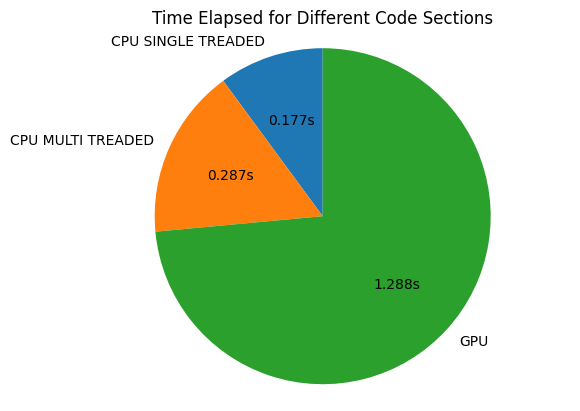

In [4]:
import numpy as np


cuda.init()
dev = cuda.Device(0)
ctx = dev.make_context()

start_time=time.time()




kernel_code = """
__global__ void filter_and_count(int *text_ids, int *stop_word_ids, int *word_freq, int text_len, int stop_len) {
    int idx = threadIdx.x + blockIdx.x * blockDim.x;
    if (idx < text_len) {
        int word_id = text_ids[idx];
        bool is_stop_word = false;

        for (int i = 0; i < stop_len; i++) {
            if (word_id == stop_word_ids[i]) {
                is_stop_word = true;
                break;
            }
        }

        if (!is_stop_word) {
            atomicAdd(&word_freq[word_id], 1);
        }
    }
}
"""


mod = SourceModule(kernel_code)
filter_and_count = mod.get_function("filter_and_count")


words = re.findall(r'\b[a-zA-Z]+(?:-[a-zA-Z]+)?\b', raw_text.lower())
word_to_id = {}
id_to_word = {}
text_ids = []
stop_word_ids = set()
current_id = 0

for word in words + list(f_stopW):
    if word not in word_to_id:
        word_to_id[word] = current_id
        id_to_word[current_id] = word
        current_id += 1


    if min_length <= len(word) <= max_length:
        text_ids.append(word_to_id[word])


    if word in f_stopW:
        stop_word_ids.add(word_to_id[word])

text_ids = np.array(text_ids, dtype=np.int32)
stop_word_ids = np.array(list(stop_word_ids), dtype=np.int32)

text_ids_gpu = cuda.mem_alloc(text_ids.nbytes)
stop_word_ids_gpu = cuda.mem_alloc(stop_word_ids.nbytes)
word_freq_gpu = cuda.mem_alloc(len(word_to_id) * np.int32(0).nbytes)


word_freq = np.zeros(len(word_to_id), dtype=np.int32)
cuda.memcpy_htod(text_ids_gpu, text_ids)
cuda.memcpy_htod(stop_word_ids_gpu, stop_word_ids)
cuda.memcpy_htod(word_freq_gpu, word_freq)


block_size = 256
grid_size = (len(text_ids) + block_size - 1) // block_size
filter_and_count(text_ids_gpu, stop_word_ids_gpu, word_freq_gpu, np.int32(len(text_ids)), np.int32(len(stop_word_ids)), block=(block_size, 1, 1), grid=(grid_size, 1))
ctx.synchronize()

cuda.memcpy_dtoh(word_freq, word_freq_gpu)

filtered_word_counts = {}
for idx, count in enumerate(word_freq):
    if count > 0:
        word = id_to_word[idx]
        filtered_word_counts[word] = count


most_frequent_word = max(filtered_word_counts, key=filtered_word_counts.get)
most_frequent_count = filtered_word_counts[most_frequent_word]
least_frequent_word = min(filtered_word_counts, key=filtered_word_counts.get)
least_frequent_count = filtered_word_counts[least_frequent_word]


print(f"Most frequent word: '{most_frequent_word}' with {most_frequent_count} occurrences")
print(f"Least frequent word: '{least_frequent_word}' with {least_frequent_count} occurrences")
print(f"Total number of unique filtered words: {np.sum(filtered_word_counts)}")
update_pie_chart("GPU", (time.time()-start_time))
word_freq_gpu.free()
ctx.pop()

Most frequent word: 'that' with 3100 occurrences
Least frequent word: 'january' with 1 occurrences
Total number of unique filtered words: 11235


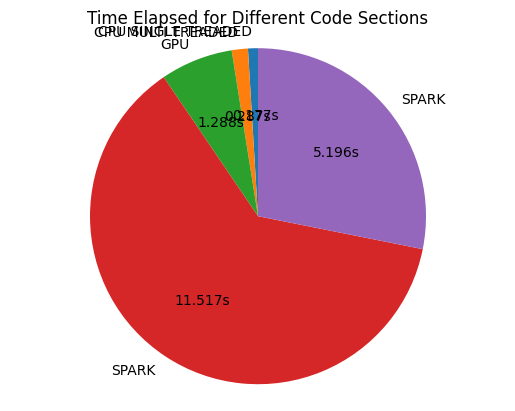

In [7]:
from pyspark.sql import SparkSession
start_time=time.time()

def clean_text(text):
    return re.findall(r'\b[a-zA-Z]+\b', text.lower())

# Vytvoření SparkSession
spark = SparkSession.builder.appName("WordCount").getOrCreate()


lines = spark.sparkContext.parallelize(raw_text.splitlines())


word_counts = (
    lines.flatMap(clean_text)
         .filter(lambda word: 4 <= len(word) <= 8 and word not in f_stopW)
         .map(lambda word: (word, 1))
         .reduceByKey(lambda a, b: a + b)
)


most_common_words = word_counts.sortBy(lambda x: x[1], ascending=True).collect()


most_frequent_word = most_common_words[-1][0]
most_frequent_count = most_common_words[-1][1]
least_frequent_word = most_common_words[0][0]
least_frequent_count = most_common_words[0][1]

# Output results
print(f"Most frequent word: '{most_frequent_word}' with {most_frequent_count} occurrences")
print(f"Least frequent word: '{least_frequent_word}' with {least_frequent_count} occurrences")
print(f"Total number of unique filtered words: {len(most_common_words)}")
update_pie_chart("SPARK", (time.time()-start_time))
# Ukončení SparkSession
spark.stop()
